# EduHamuy AI Search — Indexación y búsqueda documental con TF-IDF

Este notebook construye y valida el índice de búsqueda documental como parte del proyecto EduHamuy.
<br>

páginas de ejemplos:

*  DEV: https://dev.eduhamuy.com
*  TEST: https://test.eduhamuy.com
*  PROD: https://eduhamuy.com

<br>

El flujo completo es:

```text
PDFs en Azure Blob Storage
        ↓
Extracción y limpieza del texto
        ↓
Vectorizador TF-IDF y matriz dispersa
        ↓
Artefactos en Azure Blob Storage
        ↓
Backend eduhamuy-ai y endpoint /search
```

Las credenciales se leen desde **Google Colab User Secrets**. Los PDFs y los artefactos generados permanecen en Azure Blob Storage y no se guardan en Git.

## 1. Objetivo y flujo general


El objetivo es convertir una colección de documentos PDF en un índice TF-IDF reutilizable. El backend no vuelve a procesar todos los PDFs para cada consulta: carga los artefactos generados y calcula la similitud entre la consulta y los documentos indexados.

Este notebook cubre la indexación, la persistencia, la recarga, la búsqueda y algunos análisis exploratorios.

## 2. Instalación de dependencias

Ejecuta esta celda una vez por sesión de Colab.

In [1]:
!pip install -q pypdf nltk scikit-learn azure-storage-blob joblib scipy pandas matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.2/438.2 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.9/220.9 kB 8.6 MB/s eta 0:00:00


## 3. Importación de librerías

Todas las importaciones se mantienen juntas para que el notebook pueda ejecutarse de arriba hacia abajo.

In [2]:
import io
import re
import warnings
from io import BytesIO

import joblib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import pypdf
import scipy.sparse
import seaborn as sns
from azure.storage.blob import BlobServiceClient
from google.colab import userdata
from pypdf import PdfReader
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## 4. Descarga de recursos NLTK

Estos recursos permiten tokenizar el texto y eliminar palabras vacías en español.

In [3]:
def ensure_nltk_resource(resource_path, resource_name):
    try:
        nltk.data.find(resource_path)
    except LookupError:
        nltk.download(resource_name)


ensure_nltk_resource("tokenizers/punkt", "punkt")
ensure_nltk_resource("tokenizers/punkt_tab", "punkt_tab")
ensure_nltk_resource("corpora/stopwords", "stopwords")

print("Recursos NLTK disponibles.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Recursos NLTK disponibles.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## 5. Configuración segura de Azure Blob Storage

El SAS se obtiene desde Google Colab User Secrets. Nunca se imprime ni se escribe directamente en el notebook.

In [4]:
account = (userdata.get("AZURE_STORAGE_ACCOUNT") or "").strip()
sas = (userdata.get("AZURE_STORAGE_SAS") or "").strip().lstrip("?")

if not account or not sas:
    raise ValueError(
        "Configura AZURE_STORAGE_ACCOUNT y AZURE_STORAGE_SAS en Colab User Secrets."
    )

print(f"Cuenta Azure configurada: {account}")
print("SAS configurado de forma segura.")

Cuenta Azure configurada: steduhamuyshared
SAS configurado de forma segura.


## 6. Conexión a los contenedores

Se utilizan dos contenedores privados:

- `ai-source-pdfs`: documentos PDF originales.
- `ai-artifacts`: CSV, vectorizador y matriz TF-IDF.

In [5]:
service = BlobServiceClient(
    account_url=f"https://{account}.blob.core.windows.net",
    credential=sas,
)

source_container = service.get_container_client("ai-source-pdfs")
artifact_container = service.get_container_client("ai-artifacts")

print("Contenedores Azure configurados: ai-source-pdfs y ai-artifacts.")

Contenedores Azure configurados: ai-source-pdfs y ai-artifacts.


## 7. Lectura y extracción de texto de los PDFs

Se descargan los PDFs desde Azure Blob Storage en memoria. No se crean archivos PDF locales ni se muestran fragmentos completos del contenido en las salidas guardadas del notebook.

In [9]:
print("Buscando archivos PDF en ai-source-pdfs...\n")

all_extracted_texts = {}
skipped_due_to_error = []
skipped_due_to_no_text = []
processed_count = 0

for blob in source_container.list_blobs():
    if not blob.name.lower().endswith(".pdf"):
        continue

    try:
        pdf_bytes = source_container.download_blob(blob.name).readall()
        reader = PdfReader(BytesIO(pdf_bytes))
        extracted_text = ""

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            for page in reader.pages:
                page_text = page.extract_text()
                if page_text:
                    extracted_text += page_text + "\n"

        if extracted_text.strip():
            all_extracted_texts[blob.name] = extracted_text
            processed_count += 1

            print(
                f"{processed_count}. {blob.name} "
                f"({len(reader.pages)} páginas, "
                f"{len(extracted_text)} caracteres)",
                flush=True,
            )
        else:
            skipped_due_to_no_text.append(blob.name)

    except pypdf.errors.PdfReadError:
        skipped_due_to_error.append(blob.name)
    except Exception as exc:
        print(f"No se pudo procesar {blob.name}: {type(exc).__name__}")
        skipped_due_to_error.append(blob.name)

print("\n")
print(f"Documentos con texto extraído: {len(all_extracted_texts)}")
print(f"Documentos sin texto: {len(skipped_due_to_no_text)}")
print(f"Documentos con error: {len(skipped_due_to_error)}")

Buscando archivos PDF en ai-source-pdfs...

1. 1+El+que+tiene+que+pensar+soy+yo,+no+la+computadora.pdf (15 páginas, 39436 caracteres)
2. 1+Galindo.pdf (20 páginas, 56585 caracteres)
3. 1+La+Carrera+de+Trabajo+Social+UMSS.+Esbozo+historico,+eficiencia+educativa+interna+y+desafíos+para+la+transformación+curricular.pdf (27 páginas, 58362 caracteres)
4. 1+Raciolingüismo+en+adultos+mayores.pdf (19 páginas, 47318 caracteres)
5. 1.+B581.pdf (25 páginas, 50787 caracteres)
6. 1.+Los+trabajadores+sociales+no+somos+de+piedra+-+Nicole+Camacho+Camacho.pdf (16 páginas, 33397 caracteres)
7. 1.+Perdiendo+contacto_Marina_Arratia.pdf (32 páginas, 57831 caracteres)
8. 1.pdf (18 páginas, 28977 caracteres)
9. 10+IDENTIDADES+5+Proyecto-Grisel+Aguila+y+Josué+Valencia.pdf (14 páginas, 40506 caracteres)
10. 10+Inteligencia+Artificial+basada+en+tecnologia+como+posible+Herramienta+para+la+mejora+de+la+calidad+de+vida+de+las+personas+con+discapacidad.pdf (12 páginas, 30069 caracteres)
11. 11+uso+de+aparatos+m

## 8. Creación y preprocesamiento del DataFrame

Cada fila representa un documento. Se conservan la ruta del blob, el título, el texto y el número de palabras. La columna `cleaned_text` se utiliza para construir el índice, pero no es necesaria para el contrato mínimo del backend.

In [13]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    normalized = text.lower()
    normalized = re.sub(r"\d+", "", normalized)
    normalized = re.sub(r"[^a-záéíóúüñ\s]", "", normalized)
    normalized = re.sub(r"\s+", " ", normalized).strip()

    tokens = word_tokenize(normalized, language="spanish")
    stop_words_spanish = set(stopwords.words("spanish"))
    return " ".join(token for token in tokens if token not in stop_words_spanish)


data = [
    {"document_path": path, "text_content": text}
    for path, text in all_extracted_texts.items()
]
df_documents = pd.DataFrame(data)

if df_documents.empty:
    raise ValueError("No se extrajo texto de ningún PDF.")

df_documents["document_title"] = (
    df_documents["document_path"]
    .str.replace(".pdf", "", regex=False)
    .str.replace("+", " ", regex=False)
    .str.strip()
)
df_documents["document_words"] = df_documents["text_content"].str.split().str.len()
df_documents["cleaned_text"] = df_documents["text_content"].apply(preprocess_text)

print(f"Dimensiones del DataFrame: {df_documents.shape}")
display(df_documents[["document_title", "document_words"]].head())


Dimensiones del DataFrame: (216, 5)


,document_title,document_words
0,"1 El que tiene que pensar soy yo, no la comput...",6260
1,1 Galindo,8473
2,1 La Carrera de Trabajo Social UMSS. Esbozo hi...,9314
3,1 Raciolingüismo en adultos mayores,6686
4,1. B581,6891


## 9. Construcción del índice TF-IDF

Aquí se ajusta el vectorizador sobre todos los documentos (`fit`) y se transforma cada documento en un vector numérico (`transform`). No es aprendizaje supervisado: no hay una variable objetivo ni etiquetas.

In [14]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(df_documents["cleaned_text"])

print(f"Matriz TF-IDF: {X_tfidf.shape}")
print(f"Tamaño del vocabulario: {len(tfidf_vectorizer.vocabulary_)}")
print("Primeras características:")
print(tfidf_vectorizer.get_feature_names_out()[:50])

Matriz TF-IDF: (216, 64186)
Tamaño del vocabulario: 64186
Primeras características:
['aa' 'aachas' 'aae' 'aafectarageneraciondeempleosyalaparatocientifico'
 'aan' 'aanalyst' 'aao' 'aapp' 'aapt' 'aar' 'aashto' 'aavv' 'ab' 'aba'
 'abad' 'abadio' 'abadías' 'abajar' 'abajo' 'abaloria' 'abalorios'
 'abalospampa' 'aban' 'abanderada' 'abanderados' 'abanderar' 'abando'
 'abandona' 'abandonada' 'abandonadas' 'abandonado' 'abandonados'
 'abandonamos' 'abandonan' 'abandonando' 'abandonar' 'abandonara'
 'abandonarlo' 'abandonaron' 'abandone' 'abandonen' 'abandono' 'abandonó'
 'abanico' 'abansada' 'abaratan' 'abaratar' 'abarca' 'abarcaba'
 'abarcadas']


## 10. Persistencia de los artefactos

Se guardan tres artefactos en `ai-artifacts`. El backend `eduhamuy-ai` espera exactamente estos nombres.

In [15]:
# El CSV conserva los metadatos y el texto original necesarios para mostrar resultados.
df_for_storage = df_documents[
    ["document_path", "text_content", "document_title", "document_words"]
]
csv_bytes = df_for_storage.to_csv(index=False).encode("utf-8")
artifact_container.upload_blob(
    name="processed_documents.csv",
    data=csv_bytes,
    overwrite=True,
)

vectorizer_buffer = BytesIO()
joblib.dump(tfidf_vectorizer, vectorizer_buffer)
vectorizer_buffer.seek(0)
artifact_container.upload_blob(
    name="tfidf_vectorizer.joblib",
    data=vectorizer_buffer.read(),
    overwrite=True,
)

matrix_buffer = BytesIO()
scipy.sparse.save_npz(matrix_buffer, X_tfidf)
matrix_buffer.seek(0)
artifact_container.upload_blob(
    name="X_tfidf.npz",
    data=matrix_buffer.read(),
    overwrite=True,
)

print("Artefactos guardados en ai-artifacts:")
print("- processed_documents.csv")
print("- tfidf_vectorizer.joblib")
print("- X_tfidf.npz")

Artefactos guardados en ai-artifacts:
- processed_documents.csv
- tfidf_vectorizer.joblib
- X_tfidf.npz


## 11. Recarga y validación de los artefactos

Esta sección simula una nueva sesión y confirma que el backend podrá cargar los mismos artefactos desde Azure.

In [16]:
csv_loaded = artifact_container.get_blob_client("processed_documents.csv").download_blob().readall()
df_documents_loaded = pd.read_csv(BytesIO(csv_loaded))

vectorizer_loaded_bytes = artifact_container.get_blob_client(
    "tfidf_vectorizer.joblib"
).download_blob().readall()
vectorizer_loaded = joblib.load(BytesIO(vectorizer_loaded_bytes))

matrix_loaded_bytes = artifact_container.get_blob_client("X_tfidf.npz").download_blob().readall()
X_tfidf_loaded = scipy.sparse.load_npz(BytesIO(matrix_loaded_bytes))

required_columns = {"document_path", "document_title"}
missing_columns = required_columns - set(df_documents_loaded.columns)
if missing_columns:
    raise ValueError(f"Faltan columnas requeridas: {sorted(missing_columns)}")
if X_tfidf_loaded.shape[0] != len(df_documents_loaded):
    raise ValueError("Las filas de X_tfidf no coinciden con los documentos.")
if not hasattr(vectorizer_loaded, "transform"):
    raise ValueError("El vectorizador cargado no permite transformar consultas.")

print(f"CSV cargado: {df_documents_loaded.shape}")
print(f"Matriz cargada: {X_tfidf_loaded.shape}")
print("Vectorizador, matriz y metadatos validados correctamente.")
display(df_documents_loaded[["document_title", "document_words"]].head())

CSV cargado: (216, 4)
Matriz cargada: (216, 64186)
Vectorizador, matriz y metadatos validados correctamente.


,document_title,document_words
0,"1 El que tiene que pensar soy yo, no la comput...",6260
1,1 Galindo,8473
2,1 La Carrera de Trabajo Social UMSS. Esbozo hi...,9314
3,1 Raciolingüismo en adultos mayores,6686
4,1. B581,6891


## 12. Búsqueda y análisis exploratorio

La búsqueda transforma la consulta con el mismo preprocesamiento y vectorizador, calcula similitud coseno y devuelve los documentos más relevantes. K-Means y PCA son análisis opcionales; no son necesarios para el endpoint `/search`.

In [19]:
def search_documents(query, df, tfidf_matrix, vectorizer, top_n=5):
    if top_n < 1:
        raise ValueError("top_n debe ser mayor que cero.")

    cleaned_query = preprocess_text(query)
    if not cleaned_query:
        return pd.DataFrame(
            columns=["document_title", "similarity_score", "document_path"]
        )

    query_vector = vectorizer.transform([cleaned_query])
    scores = cosine_similarity(query_vector, tfidf_matrix).ravel()
    candidate_indices = scores.argsort()[::-1][:top_n]

    results = []
    for index in candidate_indices:
        score = float(scores[index])
        if score <= 0:
            continue
        results.append(
            {
                "document_title": df.iloc[int(index)]["document_title"],
                "similarity_score": round(score, 6),
                "document_path": df.iloc[int(index)]["document_path"],
            }
        )

    return pd.DataFrame(results)

queries = [
    ("educacion superior universidades", 2),
    ("salud mental VIH", 3),
    ("materias", 5),
]

for query, top_n in queries:
    print(f"\nResultados para: {query!r}")
    display(
        search_documents(
            query,
            df_documents_loaded,
            X_tfidf_loaded,
            vectorizer_loaded,
            top_n=top_n,
        )
    )


Resultados para: 'educacion superior universidades'


,document_title,similarity_score,document_path
0,2. Descolonización e interculturalidad_Finzi_...,0.103744,2.+Descolonización+e+interculturalidad_Finzi_...
1,AnalisisCualitativo,0.083880,AnalisisCualitativo.pdf



Resultados para: 'salud mental VIH'


,document_title,similarity_score,document_path
0,6 Posibles efectos consecuentes de las Intelig...,0.246222,6+Posibles+efectos+consecuentes+de+las+Intelig...
1,5,0.150391,5.pdf
2,Castro final,0.096475,Castro+final.pdf



Resultados para: 'materias'


,document_title,similarity_score,document_path
0,art6_5,0.073032,art6_5.pdf
1,1 La Carrera de Trabajo Social UMSS. Esbozo hi...,0.063209,1+La+Carrera+de+Trabajo+Social+UMSS.+Esbozo+hi...
2,Ensayo 2 Luis Moya,0.042226,Ensayo+2+Luis+Moya.pdf
3,PDF TRASPATIOS 7_2,0.036211,PDF+TRASPATIOS+7_2.pdf
4,5. Camino a la titulación_Nivia_Suarez,0.030246,5.+Camino+a+la+titulación_Nivia_Suarez.pdf


### Análisis exploratorio opcional: K-Means y PCA


Distribución de documentos por cluster:


,count
cluster,
0,41
1,67
2,108


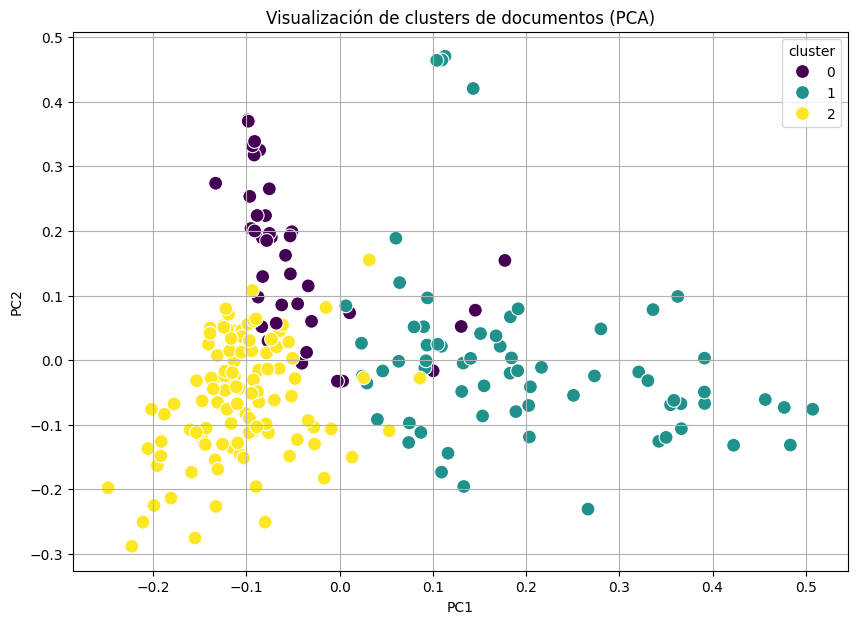

In [20]:
if len(df_documents_loaded) >= 3:
    num_clusters = min(3, len(df_documents_loaded))
    kmeans_model = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    df_documents_loaded["cluster"] = kmeans_model.fit_predict(X_tfidf_loaded)

    print("Distribución de documentos por cluster:")
    display(df_documents_loaded["cluster"].value_counts().sort_index())

    dense_matrix = X_tfidf_loaded.toarray()
    if min(dense_matrix.shape) >= 2:
        pca = PCA(n_components=2, random_state=42)
        X_pca = pca.fit_transform(dense_matrix)
        df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
        df_pca["cluster"] = df_documents_loaded["cluster"].to_numpy()

        plt.figure(figsize=(10, 7))
        sns.scatterplot(
            data=df_pca,
            x="PC1",
            y="PC2",
            hue="cluster",
            palette="viridis",
            legend="full",
            s=100,
        )
        plt.title("Visualización de clusters de documentos (PCA)")
        plt.grid(True)
        plt.show()
else:
    print("Se requieren al menos tres documentos para K-Means.")

## Resultados

Los artefactos generados por este notebook son consumidos por `eduhamuy-ai`:

```text
Azure Blob Storage
        ↓
Backend eduhamuy-ai
        ↓
GET /search?q=<término>&limit=<n>
        ↓
eduhamuy-web /api/search
        ↓
Página /buscar
```

<br>

Para actualizar el índice y verificar nuevamente: Después cargar o reemplazar los PDFs en el Azure Blob Storage

*  En el Colab: Ejecutamos nuevamente el notebook (en particular, las secciones 7–10), y verificamos la sección 11.

*  En el FE: Después de completar los pasos anteriores, hacemos Deployment del backend (eduhamuy-ai) para que abandone su caché de artefactos, y verificamos en el Fe page (https://dev.eduhamuy.com/buscar, por ejemplo).